# Baseline Walkthrough — Prediksi Tingkat Performa Siswa

**EDA + Feature Engineering dasar + Baseline model**

Notebook ini memandu langkah-langkah AWAL mengerjakan kompetisi: memahami data,
menyiapkan baseline yang jujur, dan mencoba feature engineering generik. Tujuannya
mengajarkan **cara berpikir dan alurnya**, bukan memberi jawaban akhir.

> Catatan: notebook ini sengaja **berhenti di tingkat baseline**. Transformasi
> spesifik yang membuka tiap sinyal tersembunyi tidak dibahas di sini itu
> bagian Anda untuk dieksplorasi. Di akhir ada daftar arah eksplorasi.

Alur:

0. Setup & memuat data
1. Exploratory Data Analysis (EDA)
2. Baseline model (kolom mentah)
3. Feature engineering generik (agregasi sederhana)
4. Validasi & ringkasan


## 0. Setup & Memuat Data

In [7]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", 60)
plt.rcParams["figure.figsize"] = (9, 4)
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.3

train = pd.read_csv("./kaggle/train.csv")
test  = pd.read_csv("./kaggle/test.csv")

print("train:", train.shape, "| test:", test.shape)
train.head()

train: (3200, 43) | test: (800, 42)


,id,nilai_minggu_01,nilai_minggu_02,nilai_minggu_03,nilai_minggu_04,nilai_minggu_05,nilai_minggu_06,nilai_minggu_07,nilai_minggu_08,nilai_minggu_09,nilai_minggu_10,nilai_minggu_11,nilai_minggu_12,skor_motivasi,skor_kedisiplinan,aktivitas_hari_01,aktivitas_hari_02,aktivitas_hari_03,aktivitas_hari_04,aktivitas_hari_05,aktivitas_hari_06,aktivitas_hari_07,aktivitas_hari_08,aktivitas_hari_09,aktivitas_hari_10,aktivitas_hari_11,aktivitas_hari_12,aktivitas_hari_13,aktivitas_hari_14,aktivitas_hari_15,aktivitas_hari_16,tugas_selesai,tugas_diberikan,kelas,urutan_ujian,skor_tryout,jarak_rumah_km,skor_ekstrakurikuler,indeks_kehadiran,skor_literasi,jumlah_saudara,skor_minat_belajar,target
0,0,2.6,6.4,3.6,1.0,4.4,8.5,-4.0,-0.1,-4.7,1.0,-4.7,-5.1,-0.53,-0.33,64.3,42.7,42.4,65.4,77.6,61.2,36.8,34.4,51.8,89.6,55.2,44.7,42.0,46.7,69.2,46.9,8,9,114,0.0817,72.3,0.46,0.00,-0.38,-0.24,-0.70,-0.62,3
1,1,-0.3,5.7,1.7,1.3,6.1,5.8,-0.1,-3.8,-3.1,-3.1,-1.0,1.0,-2.24,1.82,27.8,51.6,53.6,56.4,40.7,68.0,66.4,30.5,51.8,74.3,61.4,41.6,38.7,72.0,31.7,32.6,46,85,301,0.3388,41.4,-1.29,0.51,0.86,-0.70,-1.04,2.15,1
2,2,-4.8,-0.8,-3.5,-6.3,-3.7,-1.5,10.7,8.7,5.8,5.2,7.2,9.9,-1.18,-1.34,33.9,50.4,50.0,36.4,73.0,66.4,36.6,62.2,60.5,35.9,49.0,63.3,43.7,47.2,53.5,44.9,23,75,28,0.0517,73.2,-0.03,-0.33,0.14,0.80,0.26,-0.57,3
3,4,4.7,1.1,2.1,0.2,1.9,1.4,-0.5,-0.3,0.5,-1.4,-1.2,3.6,-0.60,0.69,51.0,48.0,36.5,31.8,53.0,60.7,76.7,65.1,51.1,39.0,36.4,41.9,49.1,56.2,70.6,64.5,95,110,580,0.0310,59.1,-0.20,0.24,1.68,-0.44,1.32,-0.64,1
4,5,13.3,3.5,3.4,4.1,6.2,8.7,-5.0,-6.1,-5.2,-8.2,-7.1,-6.6,-1.19,-0.67,59.2,43.0,43.6,64.6,57.7,42.2,57.7,57.7,47.9,37.2,62.3,77.4,36.5,42.2,58.5,52.8,24,32,127,0.5829,60.7,1.06,0.49,0.42,-1.36,-0.45,-1.92,3


## 1. Exploratory Data Analysis

Langkah pertama selalu memahami data: ukuran, tipe kolom, nilai hilang,
keseimbangan kelas, dan hubungan tiap kolom dengan target.

In [8]:
train.info()

<class 'pandas.DataFrame'>
RangeIndex: 3200 entries, 0 to 3199
Data columns (total 43 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   id                    3200 non-null   int64  
 1   nilai_minggu_01       3200 non-null   float64
 2   nilai_minggu_02       3200 non-null   float64
 3   nilai_minggu_03       3200 non-null   float64
 4   nilai_minggu_04       3200 non-null   float64
 5   nilai_minggu_05       3200 non-null   float64
 6   nilai_minggu_06       3200 non-null   float64
 7   nilai_minggu_07       3200 non-null   float64
 8   nilai_minggu_08       3200 non-null   float64
 9   nilai_minggu_09       3200 non-null   float64
 10  nilai_minggu_10       3200 non-null   float64
 11  nilai_minggu_11       3200 non-null   float64
 12  nilai_minggu_12       3200 non-null   float64
 13  skor_motivasi         3200 non-null   float64
 14  skor_kedisiplinan     3200 non-null   float64
 15  aktivitas_hari_01     3200 non-n

In [9]:
print("Total nilai hilang:", int(train.isna().sum().sum()))
train.describe().T.head(20)

Total nilai hilang: 0


,count,mean,std,min,25%,50%,75%,max
id,3200.0,2011.313437,1163.716874,0.00,997.750,2030.50,3013.250,3999.00
nilai_minggu_01,3200.0,0.034469,4.603547,-12.80,-3.500,-0.00,3.500,13.90
nilai_minggu_02,3200.0,0.018188,4.538317,-13.70,-3.300,0.00,3.400,13.20
nilai_minggu_03,3200.0,-0.021969,4.630500,-12.90,-3.400,-0.10,3.400,12.80
nilai_minggu_04,3200.0,0.013188,4.656880,-13.70,-3.525,0.00,3.600,14.50
nilai_minggu_05,3200.0,-0.046656,4.579261,-13.50,-3.400,-0.10,3.300,13.40
nilai_minggu_06,3200.0,-0.023094,4.595992,-13.90,-3.400,-0.15,3.300,13.20
nilai_minggu_07,3200.0,0.018969,4.566149,-15.20,-3.325,0.00,3.300,13.60
nilai_minggu_08,3200.0,0.072031,4.664008,-13.10,-3.500,0.10,3.600,14.70
nilai_minggu_09,3200.0,-0.062969,4.564136,-12.90,-3.500,-0.05,3.400,11.80


### 1.1 Distribusi kelas target

Ada 4 kelas. Kita cek keseimbangannya untuk memahami baseline tebakan acak
(1/4 = 25%) dan memastikan akurasi adalah metrik yang adil.

{0: 813, 1: 796, 2: 784, 3: 807}


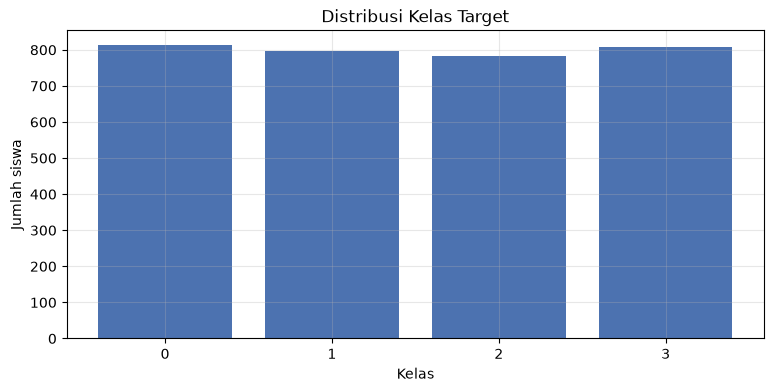

In [10]:
counts = train["target"].value_counts().sort_index()
print(counts.to_dict())

fig, ax = plt.subplots()
ax.bar(counts.index.astype(str), counts.values, color="#4C72B0")
ax.set_title("Distribusi Kelas Target")
ax.set_xlabel("Kelas"); ax.set_ylabel("Jumlah siswa")
plt.show()

Keempat kelas seimbang (~25%), jadi baseline tebakan acak ada di sekitar 0,25
dan **akurasi** adalah metrik yang tepat.

### 1.2 Sebaran beberapa kolom

Sekilas melihat bentuk distribusi kolom dari tiap kelompok berbeda. Ini membantu
kita memahami skala dan karakter data.

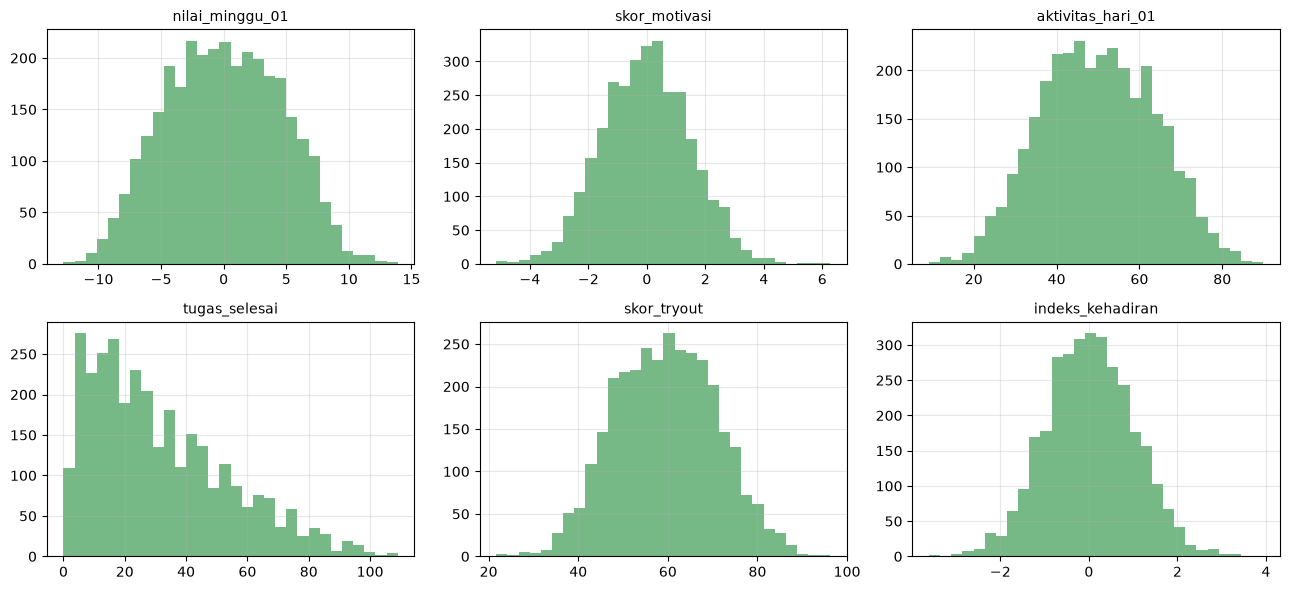

In [11]:
sample_cols = ["nilai_minggu_01", "skor_motivasi", "aktivitas_hari_01",
               "tugas_selesai", "skor_tryout", "indeks_kehadiran"]

fig, axes = plt.subplots(2, 3, figsize=(13, 6))
for col, ax in zip(sample_cols, axes.ravel()):
    ax.hist(train[col], bins=30, color="#55A868", alpha=0.8)
    ax.set_title(col, fontsize=10)
plt.tight_layout(); plt.show()

### 1.3 Seberapa informatif kolom mentah terhadap target?

Ini langkah paling penting. Kita hitung korelasi absolut tiap kolom mentah
dengan target. Bila hampir semua mendekati nol, artinya kolom mentah saja tidak
cukup, kita perlu feature engineering.

Korelasi |maks|   : 0.215
Korelasi |median| : 0.011


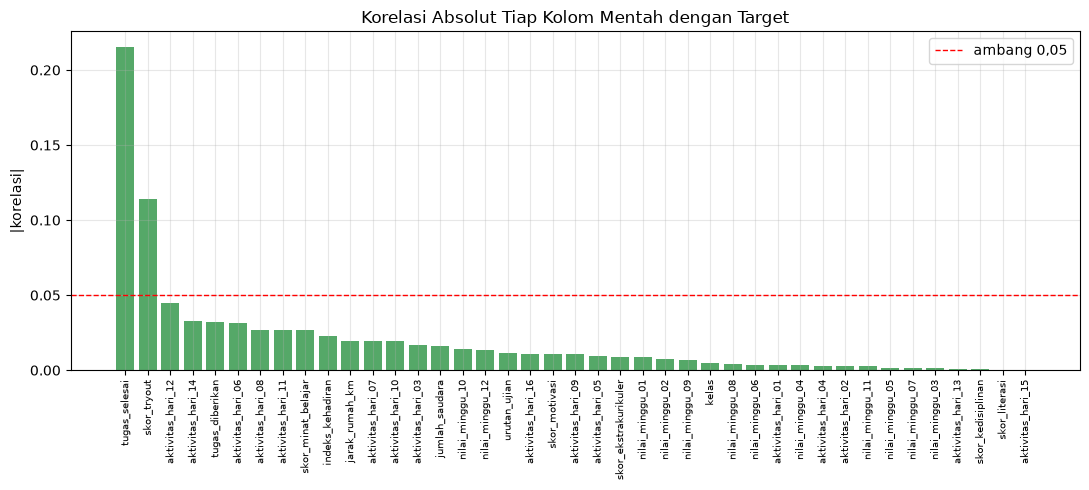

In [12]:
feat_cols = [col for col in train.columns if col not in ("id", "target")]

corr = (train[feat_cols]
        .apply(lambda col: np.corrcoef(col, train["target"])[0, 1])
        .abs()
        .sort_values(ascending=False))

print("Korelasi |maks|   :", round(corr.max(), 3))
print("Korelasi |median| :", round(corr.median(), 3))

fig, ax = plt.subplots(figsize=(11, 5))
ax.bar(range(len(corr)), corr.values, color="#55A868")
ax.axhline(0.05, color="red", ls="--", lw=1, label="ambang 0,05")
ax.set_xticks(range(len(corr)))
ax.set_xticklabels(corr.index, rotation=90, fontsize=7)
ax.set_title("Korelasi Absolut Tiap Kolom Mentah dengan Target")
ax.set_ylabel("|korelasi|"); ax.legend()
plt.tight_layout(); plt.show()

Hampir seluruh kolom berada jauh di bawah 0,05 dan yang tertinggi pun hanya
~0,2. **Tidak ada satu kolom mentah yang bisa diandalkan.** Inilah inti tantangan, dan alasan feature engineering menjadi
kunci.

### 1.4 Korelasi antar fitur

Cek cepat apakah ada kelompok kolom yang saling berkorelasi (mis. antar minggu
atau antar hari). Ini memberi petunjuk struktur, walau belum mengungkap sinyal.

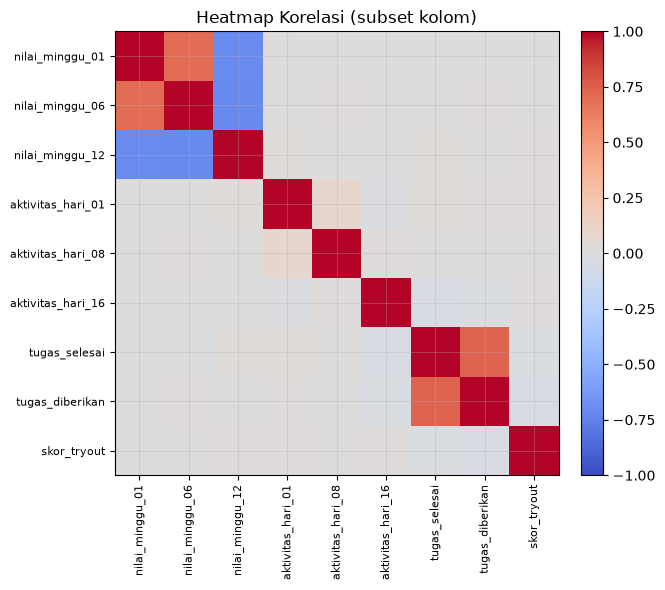

In [13]:
subset = (["nilai_minggu_01", "nilai_minggu_06", "nilai_minggu_12"] +
          ["aktivitas_hari_01", "aktivitas_hari_08", "aktivitas_hari_16"] +
          ["tugas_selesai", "tugas_diberikan", "skor_tryout"])
cmat = train[subset].corr()

fig, ax = plt.subplots(figsize=(7, 6))
im = ax.imshow(cmat, cmap="coolwarm", vmin=-1, vmax=1)
ax.set_xticks(range(len(subset))); ax.set_xticklabels(subset, rotation=90, fontsize=8)
ax.set_yticks(range(len(subset))); ax.set_yticklabels(subset, fontsize=8)
fig.colorbar(im, fraction=0.046, pad=0.04)
ax.set_title("Heatmap Korelasi (subset kolom)")
plt.tight_layout(); plt.show()

## 2. Baseline Model (Kolom Mentah)

Kita buat baseline jujur: latih model langsung pada kolom mentah dengan 5-fold 
*cross-validation*. Ini titik tolak yang harus kita kalahkan dengan FE.

In [14]:
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.model_selection import cross_val_score

y = train["target"]
X_raw = train[feat_cols]

def evaluate(features, target=y, cv=5):
    '''Akurasi CV rata-rata, Logistic Regression terstandardisasi.'''
    model = make_pipeline(StandardScaler(), LogisticRegression(max_iter=3000))
    return cross_val_score(model, features, target, cv=cv).mean()

baseline = evaluate(X_raw)
print(f"Baseline (kolom mentah, Logistic Regression): {baseline:.3f}")

Baseline (kolom mentah, Logistic Regression): 0.353


### 2.1 Apakah model yang lebih kuat menolong?

Langkah pertama biasanya "pakai model lebih canggih". Kita coba XGBoost pada
kolom mentah untuk melihat apakah itu solusinya.

In [15]:
from xgboost import XGBClassifier

xgb = XGBClassifier(tree_method="hist", n_estimators=400, max_depth=6,
                    learning_rate=0.1, random_state=0, n_jobs=-1,
                    eval_metric="mlogloss", verbosity=0)
xgb_raw = cross_val_score(xgb, X_raw, y, cv=3).mean()
print(f"XGBoost (kolom mentah): {xgb_raw:.3f}")

XGBoost (kolom mentah): 0.442


XGBoost hanya sedikit lebih baik dan masih jauh dari memuaskan. **Mengganti
kekuatan model bukan jawabannya** masalahnya ada di representasi fitur. Mari
beralih ke feature engineering.

## 3. Feature Engineering Generik

Saat menghadapi banyak kolom numerik yang dikelompokkan (mis. nilai per minggu,
aktivitas per hari), langkah generik pertama adalah membuat **fitur ringkasan
(agregasi)** dari tiap kelompok: rata-rata, simpangan baku, nilai maksimum/
minimum, dan rentang. Ini sering memberi sedikit peningkatan, dan menjadi
fondasi sebelum mencoba transformasi yang lebih spesifik.

In [16]:
week_cols = [f"nilai_minggu_{i:02d}" for i in range(1, 13)]
day_cols  = [f"aktivitas_hari_{i:02d}" for i in range(1, 17)]

fe = train[feat_cols].copy()

for name, cols in [("minggu", week_cols), ("hari", day_cols)]:
    fe[f"{name}_mean"]  = train[cols].mean(axis=1)
    fe[f"{name}_std"]   = train[cols].std(axis=1)
    fe[f"{name}_max"]   = train[cols].max(axis=1)
    fe[f"{name}_min"]   = train[cols].min(axis=1)
    fe[f"{name}_range"] = train[cols].max(axis=1) - train[cols].min(axis=1)

added = [c for c in fe.columns if c not in feat_cols]
print("Fitur ringkasan yang ditambahkan:", added)

acc_agg = evaluate(fe)
print(f"\nBaseline mentah        : {baseline:.3f}")
print(f"+ agregasi kelompok    : {acc_agg:.3f}")

Fitur ringkasan yang ditambahkan: ['minggu_mean', 'minggu_std', 'minggu_max', 'minggu_min', 'minggu_range', 'hari_mean', 'hari_std', 'hari_max', 'hari_min', 'hari_range']

Baseline mentah        : 0.353
+ agregasi kelompok    : 0.403


Agregasi sederhana memberi sedikit kenaikan. Kita lihat fitur ringkasan mana
yang paling berkorelasi dengan target, ini memberi petunjuk kelompok mana yang
menyimpan sinyal lebih kuat.

minggu_std      0.396
minggu_range    0.375
minggu_max      0.338
minggu_min      0.325
hari_range      0.050
hari_max        0.044
hari_std        0.039
hari_min        0.027
minggu_mean     0.013
hari_mean       0.013


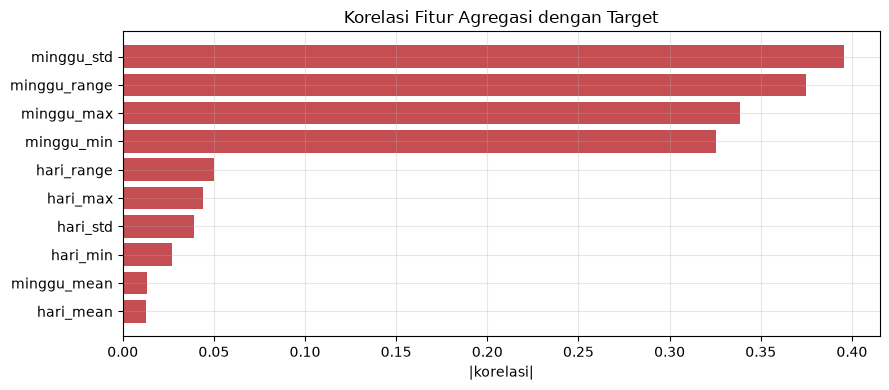

In [17]:
agg_corr = (fe[added]
            .apply(lambda col: abs(np.corrcoef(col, y)[0, 1]))
            .sort_values(ascending=False))
print(agg_corr.round(3).to_string())

fig, ax = plt.subplots()
ax.barh(agg_corr.index[::-1], agg_corr.values[::-1], color="#C44E52")
ax.set_title("Korelasi Fitur Agregasi dengan Target")
ax.set_xlabel("|korelasi|")
plt.tight_layout(); plt.show()

Beberapa fitur ringkasan (mis. simpangan baku atau rentang) tampak sedikit
lebih informatif daripada kolom mentahnya. Ini *petunjuk* bahwa "bentuk" deret
,bukan nilai tunggalnya mungkin penting. Mengejar petunjuk seperti inilah
yang akan membawa Anda ke transformasi yang lebih kuat.

### 3.1 Coba juga dengan XGBoost

Kita ukur fitur agregasi pada XGBoost untuk perbandingan.

In [18]:
acc_agg_xgb = cross_val_score(xgb, fe, y, cv=3).mean()
print(f"XGBoost kolom mentah    : {xgb_raw:.3f}")
print(f"XGBoost + agregasi      : {acc_agg_xgb:.3f}")

XGBoost kolom mentah    : 0.442
XGBoost + agregasi      : 0.452


## 4. Ringkasan Sementara & Submisi Baseline

Kita rangkum perolehan sejauh ini, lalu buat submisi baseline. Submisi ini
belum kompetitif, tujuannya memastikan alur train → FE → predict → file
submisi berjalan benar, sehingga nanti tinggal mengganti bagian FE-nya.

In [19]:
summary = pd.DataFrame([
    ("Linear  — kolom mentah", baseline),
    ("Linear  — + agregasi",   acc_agg),
    ("XGBoost — kolom mentah",  xgb_raw),
    ("XGBoost — + agregasi",    acc_agg_xgb),
], columns=["pipeline", "akurasi_cv"])
print(summary.to_string(index=False))

              pipeline  akurasi_cv
Linear  — kolom mentah    0.353125
  Linear  — + agregasi    0.403438
XGBoost — kolom mentah    0.441873
  XGBoost — + agregasi    0.451872


In [20]:
def make_features(df):
    '''FE generik (agregasi kelompok). Terapkan identik ke train & test.'''
    out = df[[c for c in df.columns if c not in ("id", "target")]].copy()
    wk = [f"nilai_minggu_{i:02d}" for i in range(1, 13)]
    dy = [f"aktivitas_hari_{i:02d}" for i in range(1, 17)]
    for name, cols in [("minggu", wk), ("hari", dy)]:
        out[f"{name}_mean"]  = df[cols].mean(axis=1)
        out[f"{name}_std"]   = df[cols].std(axis=1)
        out[f"{name}_max"]   = df[cols].max(axis=1)
        out[f"{name}_min"]   = df[cols].min(axis=1)
        out[f"{name}_range"] = df[cols].max(axis=1) - df[cols].min(axis=1)
    return out

X_train = make_features(train)
X_test  = make_features(test)

model = make_pipeline(StandardScaler(), LogisticRegression(max_iter=3000))
model.fit(X_train, y)
pred = model.predict(X_test)

submission = pd.DataFrame({"id": test["id"], "target": pred})
submission.to_csv("submission_baseline.csv", index=False)
print("submission_baseline.csv tersimpan.")
submission.head()

submission_baseline.csv tersimpan.


,id,target
0,3,3
1,12,2
2,14,3
3,18,3
4,28,1
